In [1]:
# https://docs.opencv.org/3.4/d4/d61/tutorial_warp_affine.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html#scipy.stats.rv_discrete
# https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html
# https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
# https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html

# https://scikit-image.org/docs/stable/auto_examples/edges/plot_contours.html
# https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html#sphx-glr-auto-examples-applications-plot-morphology-py
# https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.inertia_tensor_eigvals
# https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.rotate

In [2]:
# import time
import logging
import numpy as np
from scipy import stats
import pywt
import matplotlib.pyplot as plt
import skimage as ski
import pyvista as pv
# import cv2 as cv
# import vtk
import glob
# from pathlib import Path

/home/alex/fenicsxEnv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# fileLogOut = logging.FileHandler('rockProcessing.log', mode = 'w')
# consoleLogOut = logging.StreamHandler()
# logging.basicConfig(handlers = (fileLogOut, consoleLogOut), level = logging.INFO)
logging.basicConfig(filename='rockProcessing.log', level = logging.INFO)
logger = logging.getLogger('logger')

In [4]:
# Get slices:
CTSources = glob.glob('block_1/im6_shared/' + 'im_*[0-9].jp2')

In [5]:
# Sort slices
CTSources = sorted(CTSources)

In [6]:
# Reading images and moments calculation
CTImages = []
imagesMoments = []

for i in np.arange(0, len(CTSources), dtype = np.int64):
    CTImages.append(ski.io.imread(CTSources[i]))
    # CTImages.append(
    #     cv.imread(
    #         str(CTSources[i]),
    #         cv.IMREAD_GRAYSCALE
    #     )
    # )
    # imagesMoments.append(cv.moments(CTImages[-1]))
    imagesMoments.append(ski.measure.moments(CTImages[-1], order=0))
    logger.info(str(CTSources[i]))
    logger.info('\tHeight: ' + str(CTImages[i].shape[0]))
    logger.info('\tWidth: ' + str(CTImages[i].shape[1]))

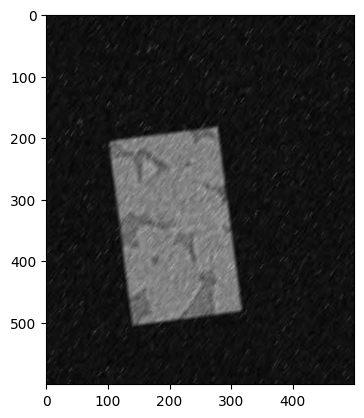

In [7]:
# Debugging
figure, axis = plt.subplots()
axis.imshow(CTImages[200], cmap='gray', vmin=0, vmax=255)

In [8]:
x = np.arange(0, len(CTImages))
# pk = np.array([imageMoment['m00'] for imageMoment in imagesMoments])
p = np.array([imageMoment[0][0] for imageMoment in imagesMoments])

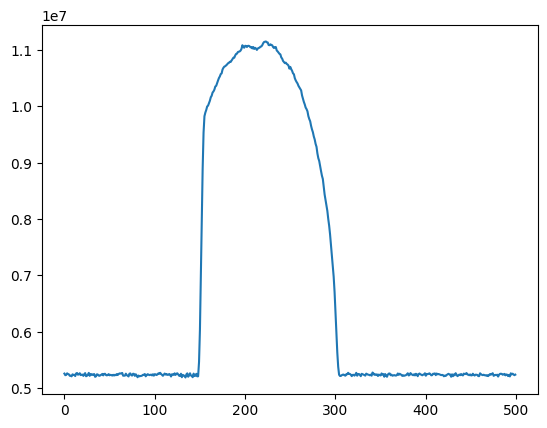

In [9]:
figure, axis = plt.subplots()
axis.plot(x, p)

In [10]:
print(pywt.wavelist(kind='discrete'))

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']


In [11]:
# print(pywt.Modes.modes)

In [12]:
p = p - np.min(p)
p = p/np.sum(p)

In [13]:
waveletType='db1'
DWTCoefficients = pywt.wavedec(p, waveletType, mode='periodic', level=4)

In [14]:
threshold = 1e-3
thresholdedDWTCoeffs = [pywt.threshold(coefficient, threshold, mode='soft') for coefficient in DWTCoefficients]

In [15]:
fp = pywt.waverec(thresholdedDWTCoeffs, waveletType, mode='periodic')

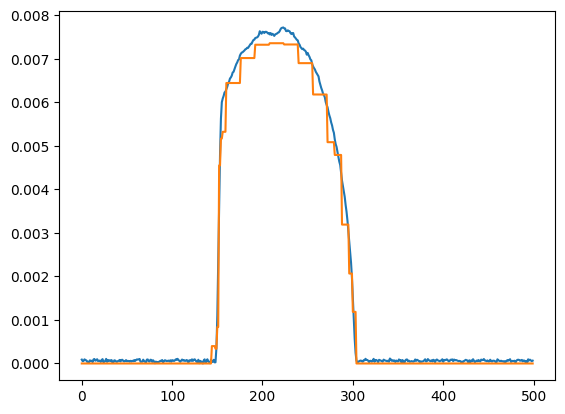

In [16]:
figure, axis = plt.subplots()
axis.plot(x, p)
axis.plot(x, fp)

In [17]:
fp = fp - np.min(fp)
fp = fp/np.sum(fp)

In [18]:
customDistribution =\
    stats.rv_discrete(
        name='customDistribution',
        values=(x, fp)
    )

In [19]:
stackRange = customDistribution.interval(0.95)

In [20]:
stackRange

(156.0, 292.0)

In [21]:
offset = (12, 12)

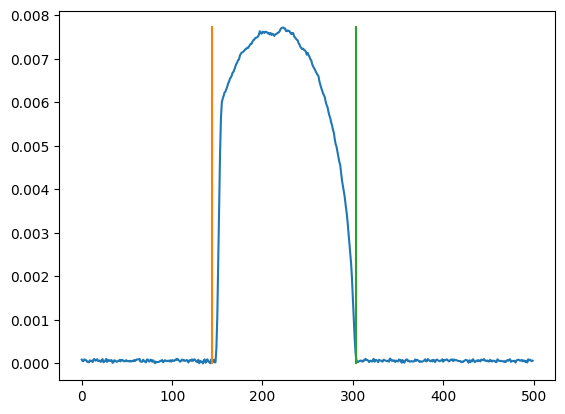

In [22]:
figure, axis = plt.subplots()
axis.plot(x, p)
axis.plot(
    [stackRange[0] - offset[0], stackRange[0] - offset[0]], [0, np.max(p)],
    [stackRange[1] + offset[1], stackRange[1] + offset[1]], [0, np.max(p)]
)

In [23]:
entropy = ski.filters.rank.entropy(CTImages[200], ski.morphology.disk(50))

In [24]:
np.min(entropy), np.max(entropy)

(3.9927225216708595, 6.71918270316492)

In [25]:
(np.min(entropy) + np.max(entropy))*0.5

5.35595261241789

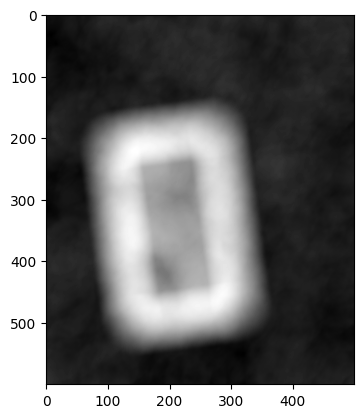

In [26]:
# Debugging
figure, axis = plt.subplots()
axis.imshow(entropy, cmap=plt.cm.gray)

In [27]:
# Find contours at a constant value
contours = ski.measure.find_contours(entropy, 5.85)
# contours = ski.measure.find_contours(CTImages[200], 150)

In [28]:
len(contours)

3

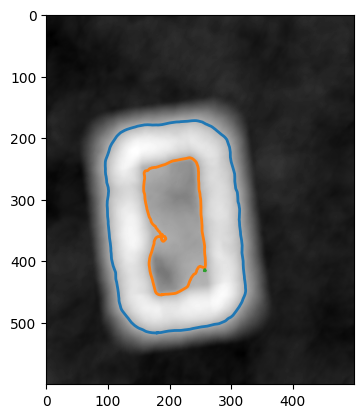

In [29]:
# Debugging
figure, axis = plt.subplots()
axis.imshow(entropy, cmap=plt.cm.gray)
for contour in contours:
    axis.plot(contour[:, 1], contour[:, 0], linewidth=2)

In [30]:
# (T, thresholdedCTImage) =\
#     cv.threshold(
#         CTImages[200],
#         100,
#         255,
#         #cv.THRESH_BINARY
#         #Binary Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = maxValue
#         #else
#             #dst(x,y) = 0
    
#         #cv.THRESH_BINARY_INV
#         #Inverse Binary Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = 0
#         #else
#             #dst(x,y) = maxValue
    
#         #cv.THRESH_TRUNC
#         #Truncate Threshold
#         #if src(x,y) > threshold
#             #dst(x,y) = threshold
#         #else
#             #dst(x,y) = src(x,y)
    
#         #cv.THRESH_TOZERO
#         #Threshold to Zero
#         #if src(x,y) > threshold
#             #dst(x,y) = src(x,y)
#         #else
#             #dst(x,y) = 0
    
#         cv.THRESH_TOZERO_INV
#         #Inverted Threshold to Zero
#         #if src(x,y) > threshold
#             #dst(x,y) = 0
#         #else
#             #dst(x,y) = src(x,y)
#     )

In [31]:
# plt.imshow(thresholdedCTImage, cmap='gray', vmin=0, vmax=255)
# plt.show()